# The Curse of Dimensionality
**ESS469 / MLGEO-2026 | Andy_CoD**

How pairwise distances between random points behave as dimensionality increases.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_points, n_pairs = 500, 3000
dims = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500]

mean_dists, min_dists, max_dists = [], [], []
for p in dims:
    pts = np.random.randn(n_points, p)
    i1 = np.random.randint(0, n_points, n_pairs)
    i2 = np.random.randint(0, n_points, n_pairs)
    same = i1 == i2; i2[same] = (i2[same] + 1) % n_points
    d = np.linalg.norm(pts[i1] - pts[i2], axis=1)
    mean_dists.append(d.mean()); min_dists.append(d.min()); max_dists.append(d.max())

mean_dists = np.array(mean_dists)
min_dists  = np.array(min_dists)
max_dists  = np.array(max_dists)
contrast   = (max_dists - min_dists) / max_dists

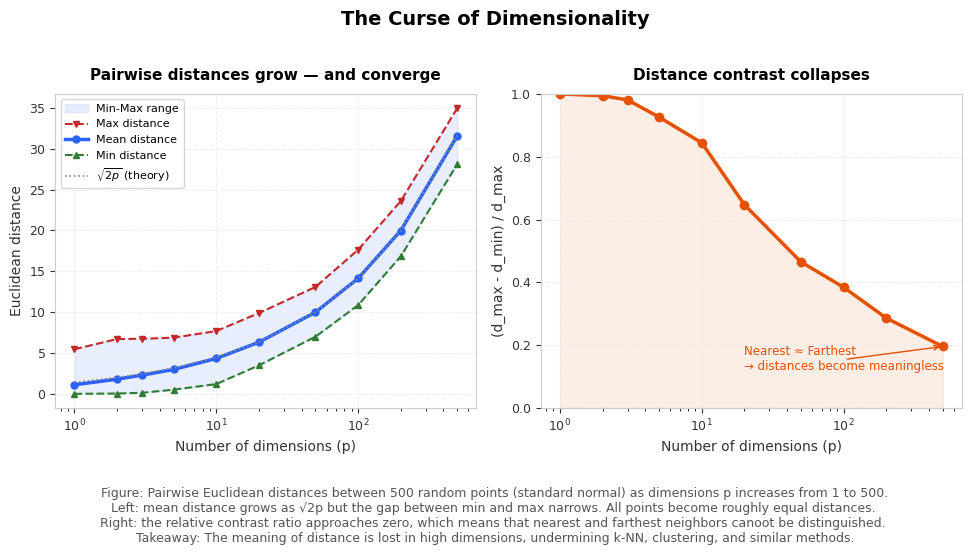

In [20]:
C_mean = '#2962ff'; C_min = '#2e7d32'; C_max = '#c62828'; C_con = '#e65100'

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('white')
    for sp in ax.spines.values(): sp.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333'); ax.yaxis.label.set_color('#333333')
    ax.grid(color='#eeeeee', ls='--', lw=0.7)
    ax.set_xscale('log')

ax = axes[0]
ax.fill_between(dims, min_dists, max_dists, color=C_mean, alpha=0.1, label='Min-Max range')
ax.plot(dims, max_dists, color=C_max, lw=1.5, ls='--', marker='v', ms=5, label='Max distance')
ax.plot(dims, mean_dists, color=C_mean, lw=2.5, marker='o', ms=5, label='Mean distance')
ax.plot(dims, min_dists, color=C_min, lw=1.5, ls='--', marker='^', ms=5, label='Min distance')
ax.plot(dims, np.sqrt(2*np.array(dims)), color='#888888', lw=1.2, ls=':', label=r'$\sqrt{2p}$ (theory)')
ax.set_xlabel('Number of dimensions (p)', fontsize=10)
ax.set_ylabel('Euclidean distance', fontsize=10)
ax.set_title('Pairwise distances grow — and converge', fontsize=11, fontweight='bold', pad=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(dims, contrast, color=C_con, lw=2.5, marker='o', ms=6)
ax.fill_between(dims, 0, contrast, color=C_con, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_xlabel('Number of dimensions (p)', fontsize=10)
ax.set_ylabel('(d_max - d_min) / d_max', fontsize=10)
ax.set_title('Distance contrast collapses', fontsize=11, fontweight='bold', pad=10)
ax.axhline(0, color='#aaaaaa', lw=0.8, ls=':')
ax.annotate('Nearest ≈ Farthest\n→ distances become meaningless',
            xy=(dims[-1], contrast[-1]), xytext=(20, 0.12),
            color=C_con, fontsize=8.5,
            arrowprops=dict(arrowstyle='->', color=C_con, lw=1))

caption = (
    'Figure: Pairwise Euclidean distances between 500 random points (standard normal) as dimensions p increases from 1 to 500.\n'
    'Left: mean distance grows as √2p but the gap between min and max narrows. All points become roughly equal distances. \n'
    'Right: the relative contrast ratio approaches zero, which means that nearest and farthest neighbors canoot be distinguished. \n'
    'Takeaway: The meaning of distance is lost in high dimensions, undermining k-NN, clustering, and similar methods.'
)
fig.text(0.5, -0.04, caption, ha='center', va='top', fontsize=9, color='#555555')
fig.suptitle('The Curse of Dimensionality', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('Andy_CoD_figure.png', dpi=180, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()